In [1]:
import os
import torch
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as T

class WiderFaceDataset(Dataset):
    def __init__(self, root_dir, annotation_file):
        self.root_dir = root_dir

        # ✅ Correct path for Kaggle structure
        self.images_dir = os.path.join(root_dir, 'WIDER_train', 'WIDER_train', 'images')
        print("📂 Images Directory:", self.images_dir)

        # ✅ Transform (important for performance)
        self.transforms = T.Compose([
            T.Resize((512, 512)),   # reduce memory usage
            T.ToTensor()
        ])

        self.data = []
        self._parse_annotations(annotation_file)

    def _parse_annotations(self, annotation_file):
        print(f"🔄 Parsing annotations from: {annotation_file}")

        with open(annotation_file, 'r') as f:
            lines = f.readlines()

        i = 0
        missing_images = 0
        total_boxes = 0

        while i < len(lines):
            filename = lines[i].strip()
            i += 1

            if not filename.endswith('.jpg'):
                continue

            num_boxes = int(lines[i].strip())
            i += 1

            boxes = []

            for _ in range(num_boxes):
                parts = list(map(int, lines[i].split()[:4]))
                x, y, w, h = parts

                x1 = x
                y1 = y
                x2 = x + w
                y2 = y + h

                # ✅ Ignore invalid boxes
                if x2 > x1 and y2 > y1:
                    boxes.append([x1, y1, x2, y2])
                    total_boxes += 1

                i += 1

            # ✅ Skip images without boxes
            if len(boxes) == 0:
                continue

            img_path = os.path.join(self.images_dir, filename)

            if os.path.exists(img_path):
                self.data.append({
                    "image_path": img_path,
                    "boxes": boxes
                })
            else:
                missing_images += 1

        print(f"✅ Loaded Images: {len(self.data)}")
        print(f"📦 Total Boxes: {total_boxes}")
        print(f"❌ Missing Images Skipped: {missing_images}")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]

        # ✅ Load image
        image = Image.open(item["image_path"]).convert("RGB")

        # ✅ Convert boxes
        boxes = torch.tensor(item["boxes"], dtype=torch.float32)

        # ✅ Labels (face = 1)
        labels = torch.ones((len(boxes),), dtype=torch.int64)

        # ✅ Target dict (Faster R-CNN format)
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        }

        # ✅ Apply transform
        image = self.transforms(image)

        return image, target

In [2]:
dataset = WiderFaceDataset(
    root_dir="/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset",
    annotation_file="/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_train_bbx_gt.txt"
)

print("🔥 Dataset loaded")
print("Total samples:", len(dataset))

📂 Images Directory: /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/WIDER_train/WIDER_train/images
🔄 Parsing annotations from: /kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_train_bbx_gt.txt
✅ Loaded Images: 12876
📦 Total Boxes: 159393
❌ Missing Images Skipped: 0
🔥 Dataset loaded
Total samples: 12876


In [3]:
import os

root = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset"

print("Root folders:", os.listdir(root))

print("\nTrain folder:", os.listdir(os.path.join(root, "WIDER_train")))
print("\nNested folder:", os.listdir(os.path.join(root, "WIDER_train", "WIDER_train")))

print("\nImages sample:",
      os.listdir(os.path.join(root, "WIDER_train", "WIDER_train", "images"))[:5])

Root folders: ['WIDER_test', 'wider_face_annotations', 'WIDER_train', 'WIDER_val']

Train folder: ['WIDER_train']

Nested folder: ['images']

Images sample: ['42--Car_Racing', '0--Parade', '22--Picnic', '11--Meeting', '16--Award_Ceremony']


🔄 Parsing bounding box annotations...
✅ Loaded 12876 robust images
🔥 Dataset perfectly ready: 12876
Using High-Speed device: cuda
Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:01<00:00, 163MB/s]  


Epoch [1/5] Step [0/3219] Loss: 1.1978
Epoch [1/5] Step [100/3219] Loss: 0.6965
Epoch [1/5] Step [200/3219] Loss: 0.5274
Epoch [1/5] Step [300/3219] Loss: 0.2013
Epoch [1/5] Step [400/3219] Loss: 0.2702
Epoch [1/5] Step [500/3219] Loss: 0.4383
Epoch [1/5] Step [600/3219] Loss: 0.4176
Epoch [1/5] Step [700/3219] Loss: 0.1442
Epoch [1/5] Step [800/3219] Loss: 0.7547
Epoch [1/5] Step [900/3219] Loss: 0.4211
Epoch [1/5] Step [1000/3219] Loss: 0.4569
Epoch [1/5] Step [1100/3219] Loss: 0.3403
Epoch [1/5] Step [1200/3219] Loss: 0.1847
Epoch [1/5] Step [1300/3219] Loss: 0.6269
Epoch [1/5] Step [1400/3219] Loss: 0.2264
Epoch [1/5] Step [1500/3219] Loss: 0.5602
Epoch [1/5] Step [1600/3219] Loss: 0.3285
Epoch [1/5] Step [1700/3219] Loss: 0.5022
Epoch [1/5] Step [1800/3219] Loss: 0.4246
Epoch [1/5] Step [1900/3219] Loss: 0.8182
Epoch [1/5] Step [2000/3219] Loss: 0.4278
Epoch [1/5] Step [2100/3219] Loss: 0.3135
Epoch [1/5] Step [2200/3219] Loss: 0.4601
Epoch [1/5] Step [2300/3219] Loss: 0.4057
Epoc

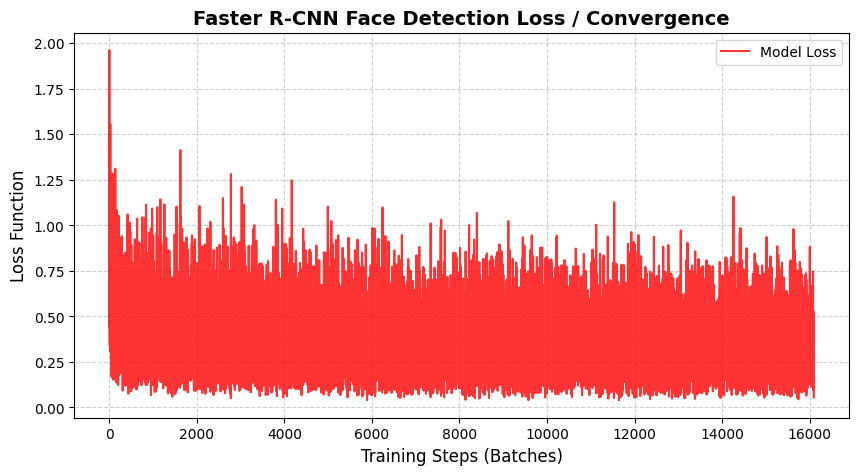

In [4]:
# ==========================================
# 🔥 IMPORTS
# ==========================================
import os
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import matplotlib.pyplot as plt

# ==========================================
# 📂 PATHS (KAGGLE INPUT)
# ==========================================
WIDER_FACE_ROOT = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset"
ANNOTATION_FILE = "/kaggle/input/datasets/iamprateek/wider-face-a-face-detection-dataset/wider_face_annotations/wider_face_split/wider_face_train_bbx_gt.txt"

# Export Paths
MODEL_SAVE_PATH = "/kaggle/working/fasterrcnn_widerface.pth"
PLOT_SAVE_PATH = "/kaggle/working/training_loss_curve.png"

# ==========================================
# 📦 DATASET CLASS
# ==========================================
class WiderFaceDataset(Dataset):
    def __init__(self, root_dir, annotation_file):
        self.images_dir = os.path.join(root_dir, 'WIDER_train', 'WIDER_train', 'images')
        
        self.transforms = T.Compose([
            T.ToTensor()
        ])
        
        self.data = []
        self._parse_annotations(annotation_file)

    def _parse_annotations(self, annotation_file):
        print("🔄 Parsing bounding box annotations...")
        with open(annotation_file, 'r') as f:
            lines = f.readlines()
            
        i = 0
        while i < len(lines):
            filename = lines[i].strip()
            i += 1
            if not filename.endswith('.jpg'):
                continue
                
            try:
                num_boxes = int(lines[i].strip())
            except ValueError:
                num_boxes = 0
                
            i += 1
            boxes = []
            
            if num_boxes == 0:
                i += 1
            else:
                for _ in range(num_boxes):
                    parts = list(map(int, lines[i].split()[:4]))
                    x1, y1, w, h = parts
                    x2, y2 = x1 + w, y1 + h
                    if x2 > x1 and y2 > y1:
                        boxes.append([x1, y1, x2, y2])
                    i += 1
                    
            if len(boxes) == 0:
                continue
            
            img_path = os.path.join(self.images_dir, *filename.split('/'))
            self.data.append({
                "image_path": img_path,
                "boxes": boxes
            })
            
        print(f"✅ Loaded {len(self.data)} robust images")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image = Image.open(item["image_path"]).convert("RGB")
        boxes = torch.tensor(item["boxes"], dtype=torch.float32)
        
        # =======================================================
        # 🟢 THE MATH FIX: Resize image AND boxes proportionally
        # =======================================================
        w_orig, h_orig = image.size
        target_size = 512
        
        # 1. Shrink Image
        image = image.resize((target_size, target_size))
        
        # 2. Calculate Shrink Ratio
        scale_x = target_size / w_orig
        scale_y = target_size / h_orig
        
        # 3. Apply Shrink Ratio to all [x1, y1, x2, y2] Bounding Boxes
        boxes[:, 0] = boxes[:, 0] * scale_x
        boxes[:, 2] = boxes[:, 2] * scale_x
        boxes[:, 1] = boxes[:, 1] * scale_y
        boxes[:, 3] = boxes[:, 3] * scale_y
        # =======================================================

        labels = torch.ones((len(boxes),), dtype=torch.int64)
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx]),
            "area": (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1]),
            "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64)
        }
        
        image = self.transforms(image)
        return image, target


# ==========================================
# 📦 COLLATE FUNCTION
# ==========================================
def collate_fn(batch):
    return tuple(zip(*batch))


# ==========================================
# 🚀 LOAD DATASET
# ==========================================
dataset = WiderFaceDataset(WIDER_FACE_ROOT, ANNOTATION_FILE)
# Safe Batch Size for massive Kaggle images
data_loader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)

print("🔥 Dataset perfectly ready:", len(dataset))


# ==========================================
# 🧠 MODEL SETUP
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using High-Speed device:", device)

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)
model.to(device)


# ==========================================
# ⚙️ OPTIMIZER
# ==========================================
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005
)

# ==========================================
# 🔥 TRAINING LOOP WITH MATPLOTLIB TRACKING
# ==========================================
EPOCHS = 5

# Metric Trackers
step_losses = []

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for i, (images, targets) in enumerate(data_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        # Track the active loss mathematically 
        loss_val = losses.item()
        total_loss += loss_val
        step_losses.append(loss_val)

        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}] Step [{i}/{len(data_loader)}] Loss: {loss_val:.4f}")

    avg_epoch_loss = total_loss / len(data_loader)
    print(f"✅ Epoch {epoch+1} Finished | Avg Loss: {avg_epoch_loss:.4f}\n")


# ==========================================
# 📈 GENERATE METRICS PLOT
# ==========================================
print("📊 Exporting Training Metrics Graph...")
plt.figure(figsize=(10, 5))
plt.plot(step_losses, label="Model Loss", color="red", linewidth=1.5, alpha=0.8)
plt.title("Faster R-CNN Face Detection Loss / Convergence", fontsize=14, fontweight='bold')
plt.xlabel("Training Steps (Batches)", fontsize=12)
plt.ylabel("Loss Function", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.savefig(PLOT_SAVE_PATH)
print(f"🎉 Loss Graph successfully generated at: {PLOT_SAVE_PATH}")

# ==========================================
# 💾 SAVE MODEL
# ==========================================
torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"🎉 Model Weights successfully saved at: {MODEL_SAVE_PATH}")